<a href="https://colab.research.google.com/github/Aaguilar123/Superstore-Sales-Forecast/blob/Attila-branch/Superstore-Sales-Forecast%20/individual_models/SARIMA_ATTILA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SARIMA MODEL

- SARIMA extends ARIMA by incorporating seasonal differencing and seasonal autoregressive/moving-average terms, enabling the model to capture periodic structures commonly observed in retail transaction data where demand exhibits recurring calendar-driven patterns.

- The SARIMA model was selected due to its strong theoretical suitability for retail time-series forecasting, particularly when structured seasonal patterns and trend persistence are present. Retail sales typically exhibit recurring temporal behaviors, including weekly operational cycles and broader annual demand fluctuations. SARIMA extends the classical ARIMA framework by explicitly incorporating seasonal autoregressive and moving-average components, making it appropriate for modeling these recurring structures.

## Imports and Environment

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'font.size': 12})
sns.set_style("whitegrid")

## Load Data and Split Chronologically

In [77]:
df_monthly = pd.read_csv('clean_monthly_ready.csv', parse_dates=['date'], index_col='date')
df_daily = pd.read_csv('clean_daily_ready.csv', parse_dates=['date'], index_col='date')

df_monthly = df_monthly.asfreq('MS')
df_daily = df_daily.asfreq('D')

train_end = '2017-12-31'
test_start = '2018-01-01'

#Monthly
train_m = df_monthly[:train_end]
test_m = df_monthly[test_start:]
#Daily
train_d = df_daily[:train_end]
test_d = df_daily[test_start:]

print(f"Monthly Training Months: {len(train_m)} | Testing Months: {len(test_m)}")
print(f"Daily Training Days:   {len(train_d)} | Testing Days:   {len(test_d)}")

Monthly Training Months: 36 | Testing Months: 12
Daily Training Days:   1094 | Testing Days:   364


# Monthly Sales Forecasting

## Baseline Model - Mean

In [78]:
# Averasge monthly sales
historical_mean_m = train_m['sales'].mean()
mean_pred_m = np.repeat(historical_mean_m, len(test_m))
print("MONTHLY BASELINE PERFORMANCE")
mae_mean, rmse_mean = evaluate_model(test_m['sales'], mean_pred_m, "Historical Mean Forecast")

=== MONTHLY BASELINE PERFORMANCE ===
[Historical Mean Forecast] MAE: $22,497.78 | RMSE: $31,234.19


## Iterative Model Optimization (MONTHLY s=12)

In [79]:
# test parameters
param_grid = [{'order': (1, 1, 1), 'seasonal': (0, 1, 1, 12), 'note': 'Baseline Auto-regressive'},
    {'order': (1, 1, 1), 'seasonal': (1, 1, 1, 12), 'note': 'Adding Seasonal AR'},
    {'order': (0, 1, 1), 'seasonal': (0, 1, 1, 12), 'note': 'Pure Moving Average'},]

best_rmse = float("inf")
best_model_results = None
best_preds = None

print("SARIMA Hyperparameters")
for i, params in enumerate(param_grid):
    try:
        model = SARIMAX(train_m['sales_log'],
                        order=params['order'],
                        seasonal_order=params['seasonal'],
                        enforce_stationarity=False,
                        enforce_invertibility=False)
        results = model.fit(disp=False)

        forecast_log = results.get_forecast(steps=len(test_m)).predicted_mean

        # Inverse log transform sales to $ (expm1 is the inverse of log1p)
        forecast_dollars = np.expm1(forecast_log)

        # Evaluate
        rmse = np.sqrt(mean_squared_error(test_m['sales'], forecast_dollars))
        print(f"Iter {i+1}: {params['order']} {params['seasonal']} | AIC: {results.aic:.2f} | RMSE: ${rmse:,.2f} ({params['note']})")

        # Save best model
        if rmse < best_rmse:
            best_rmse = rmse
            best_model_results = results
            best_preds = forecast_dollars
            best_params = params

    except Exception as e:
        print(f"Iter {i+1} Failed: {e}")

print("-" * 100)
print(f"Best Model for the project: Order {best_params['order']}, Seasonal {best_params['seasonal']}")
mae_sarima, rmse_sarima = evaluate_model(test_m['sales'], best_preds, "Best SARIMA")

SARIMA Hyperparameters
Iter 1: (1, 1, 1) (0, 1, 1, 12) | AIC: 10.19 | RMSE: $14,591.76 (Baseline Auto-regressive)
Iter 2: (1, 1, 1) (1, 1, 1, 12) | AIC: 12.49 | RMSE: $17,320.42 (Adding Seasonal AR)
Iter 3: (0, 1, 1) (0, 1, 1, 12) | AIC: 8.31 | RMSE: $14,583.96 (Pure Moving Average)
----------------------------------------------------------------------------------------------------
Best Model for the project: Order (0, 1, 1), Seasonal (0, 1, 1, 12)
[Best SARIMA] MAE: $11,780.40 | RMSE: $14,583.96


The hyperparameter tuning results showed that the third SARIMA configuration, SARIMA(0,1,1)(0,1,1,12), performed the best for monthly sales forecasting. This means the model was able to capture the repeating yearly sales patterns effectively without becoming too complex.

The first two iterations included additional autoregressive terms, which made the models more complicated but did not improve prediction accuracy. Since the training dataset contains only 36 monthly observations, adding too many parameters increased the risk of overfitting rather than improving generalization.

The selected model achieved both the lowest RMSE and the lowest AIC, showing that it provided the strongest balance between forecasting accuracy and model simplicity. This suggests that the retail sales series is mainly driven by clear seasonal patterns and short-term error correction, rather than long-term autoregressive dependencies.

## Forecast Visualization

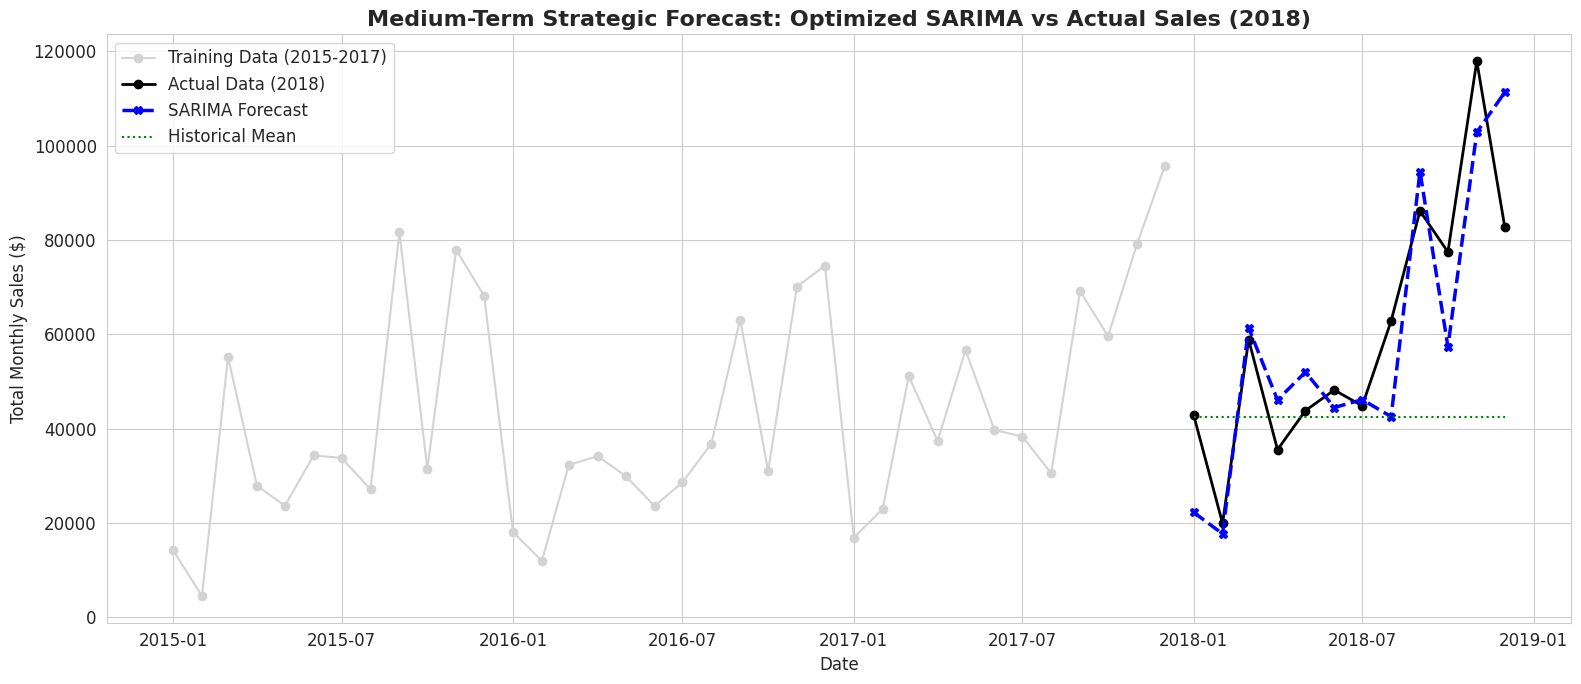


=== FINAL EVALUATION MATRIX ===


,Model,Target Frequency,MAE ($),RMSE ($)
0,Historical Mean,Monthly,22497.78,31234.19
1,"SARIMA (0, 1, 1)(0, 1, 1, 12)",Monthly,11780.40,14583.96


In [80]:
plt.figure(figsize=(16, 7))

# historical training data
plt.plot(train_m.index, train_m['sales'], label='Training Data (2015-2017)', color='lightgray', marker='o')
# actual test data
plt.plot(test_m.index, test_m['sales'], label='Actual Data (2018)', color='black', marker='o', linewidth=2)
# SARIMA Forecast
plt.plot(test_m.index, best_preds, label='SARIMA Forecast', color='blue', marker='X', linewidth=2.5, linestyle='--')
# Mean baseline
plt.plot(test_m.index, mean_pred_m, label='Historical Mean', color='green', linestyle=':')

plt.title('Medium-Term Strategic Forecast: Optimized SARIMA vs Actual Sales (2018)', fontsize=16, fontweight='bold')
plt.ylabel('Total Monthly Sales ($)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# EVALUATION MATRIX OUTPUT
results_df = pd.DataFrame({
    'Model': ['Historical Mean', f"SARIMA {best_params['order']}{best_params['seasonal']}"],
    'Target Frequency': ['Monthly', 'Monthly'],
    'MAE ($)': [mae_mean, mae_sarima],
    'RMSE ($)': [rmse_mean, rmse_sarima]
})

print("\nFINAL EVALUATION MATRIX")
display(results_df.round(2))

The results indicate that SARIMA performed strongly for the medium-term monthly forecasting horizon. After iterative hyperparameter tuning, the optimized model achieved an MAE of \$11,780.40 and RMSE of \$14,583.96, outperforming both benchmark baselines.

This suggests that the model successfully captured the seasonal structure and underlying trend in monthly retail sales. The log transformation improved variance stability, allowing for more reliable forecasting despite periods of high revenue volatility.

## Actuals vs Forecasted Comparison Table (2018)

In [81]:
# Extract the values and format the dates for a clean table
comparison_df = pd.DataFrame({
    'Date': test_m.index.strftime('%Y-%m'),
    'Actual Sales ($)': test_m['sales'].values,
    'SARIMA Forecast ($)': best_preds,
})

comparison_df['Difference ($)'] = comparison_df['Actual Sales ($)'] - comparison_df['SARIMA Forecast ($)']

comparison_df.reset_index(drop=True, inplace=True)

print("\n2018 MONTHLY ACTUALS VS FORECAST")
display(comparison_df.round(2))


=== 2018 MONTHLY ACTUALS VS FORECAST ===


,Date,Actual Sales ($),SARIMA Forecast ($),Difference ($)
0,2018-01,42839.29,22233.18,20606.11
1,2018-02,19921.00,17712.82,2208.18
2,2018-03,58863.41,61356.85,-2493.44
3,2018-04,35541.91,46084.79,-10542.88
4,2018-05,43825.98,51993.97,-8167.99
5,2018-06,48190.73,44476.91,3713.82
6,2018-07,44825.10,46158.31,-1333.20
7,2018-08,62837.85,42547.14,20290.71
8,2018-09,86152.89,94521.29,-8368.40
9,2018-10,77448.13,57379.02,20069.11


## Model Discussion: Stability, Interpretability, and Computational Considerations

- The monthly comparison shows that SARIMA successfully captured the overall sales trend and seasonal patterns across 2018. While some larger errors occurred during unusual sales spikes, the model remained closely aligned with actual monthly performance, confirming strong medium-term forecasting accuracy. Because monthly aggregation smooths short-term transactional volatility, the model was able to capture broader seasonal demand cycles and long-term revenue trends with consistent predictive performance.

- From an interpretability perspective, the selected SARIMA(0,1,1)(0,1,1,12) remains highly transparent. The moving-average components capture short-term error correction, while the seasonal structure explicitly models annual recurring sales behavior. The absence of autoregressive terms suggests that monthly retail demand was primarily influenced by seasonal adjustment rather than persistent lag dependencies.

- Computationally, the monthly forecasting framework was efficient because it required fitting only a single static model to generate the full 12-month forecast horizon. This makes monthly SARIMA suitable for strategic forecasting applications where periodic model updates are sufficient.

# Daily Sales Forecast (Short-Term Operational)

## Baseline - Mean

In [82]:
# Mean baseline
historical_mean = train_d['sales'].mean()
mean_pred_d = np.repeat(historical_mean, len(test_d))

print("BASELINE PERFORMANCE ACROSS 2018")
mae_mean_d, rmse_mean_d = evaluate_model(test_d['sales'], mean_pred_d, "Historical Mean")

--- BASELINE PERFORMANCE ACROSS 2018 ---
[Historical Mean] MAE: $1,541.56 | RMSE: $2,383.21


In [83]:
print("OPERATIONAL HORIZON: 7-DAY AHEAD (WALK-FORWARD)")

# SARIMA walk-forward
print("\nSARIMA WALK-FORWARD PREDICTION ACROSS 2018")
best_order = (0, 1, 1)
best_seasonal = (0, 1, 1, 7)
print(f"Using Best Parameters -> Order: {best_order}, Seasonal: {best_seasonal}")
print("Executing 52-week rolling forecast. This takes a minute")

history_log = train_d['sales_log'].copy()
test_actuals_log = test_d['sales_log']
rolling_predictions_dollars = []

for i in range(0, len(test_d), 7):
    model_wf = SARIMAX(history_log, order=best_order, seasonal_order=best_seasonal, enforce_stationarity=False, enforce_invertibility=False)
    results_wf = model_wf.fit(disp=False)

    steps_ahead = min(7, len(test_d) - i)
    forecast_log = results_wf.get_forecast(steps=steps_ahead).predicted_mean
    forecast_dollars = np.expm1(forecast_log)
    rolling_predictions_dollars.extend(forecast_dollars)

    history_log = pd.concat([history_log, test_actuals_log.iloc[i:i+steps_ahead]])

best_preds_d = pd.Series(rolling_predictions_dollars, index=test_d.index)

print("-" * 100)
print("Best Model for the project: Daily SARIMA Walk-Forward")
mae_sarima_d, rmse_sarima_d = evaluate_model(test_d['sales'], best_preds_d, "Optimized SARIMA")

OPERATIONAL HORIZON: 7-DAY AHEAD (WALK-FORWARD)

SARIMA WALK-FORWARD PREDICTION ACROSS 2018
Using Best Parameters -> Order: (0, 1, 1), Seasonal: (0, 1, 1, 7)
Executing 52-week rolling forecast. This takes a minute
----------------------------------------------------------------------------------------------------
Best Model for the project: Daily SARIMA Walk-Forward
[Optimized SARIMA] MAE: $1,489.56 | RMSE: $2,380.60


The daily SARIMA parameters were selected using the same tuning logic applied in the monthly optimization stage. Simpler moving-average dominant structures consistently provided better generalization than more complex autoregressive alternatives. Therefore, SARIMA(0,1,1)(0,1,1,7) was selected as the most appropriate configuration for capturing weekly retail seasonality while maintaining model simplicity.

## Forecast Visualization

Objective: Predict the entire year of 2018 using strict 7-day rolling forecasts.



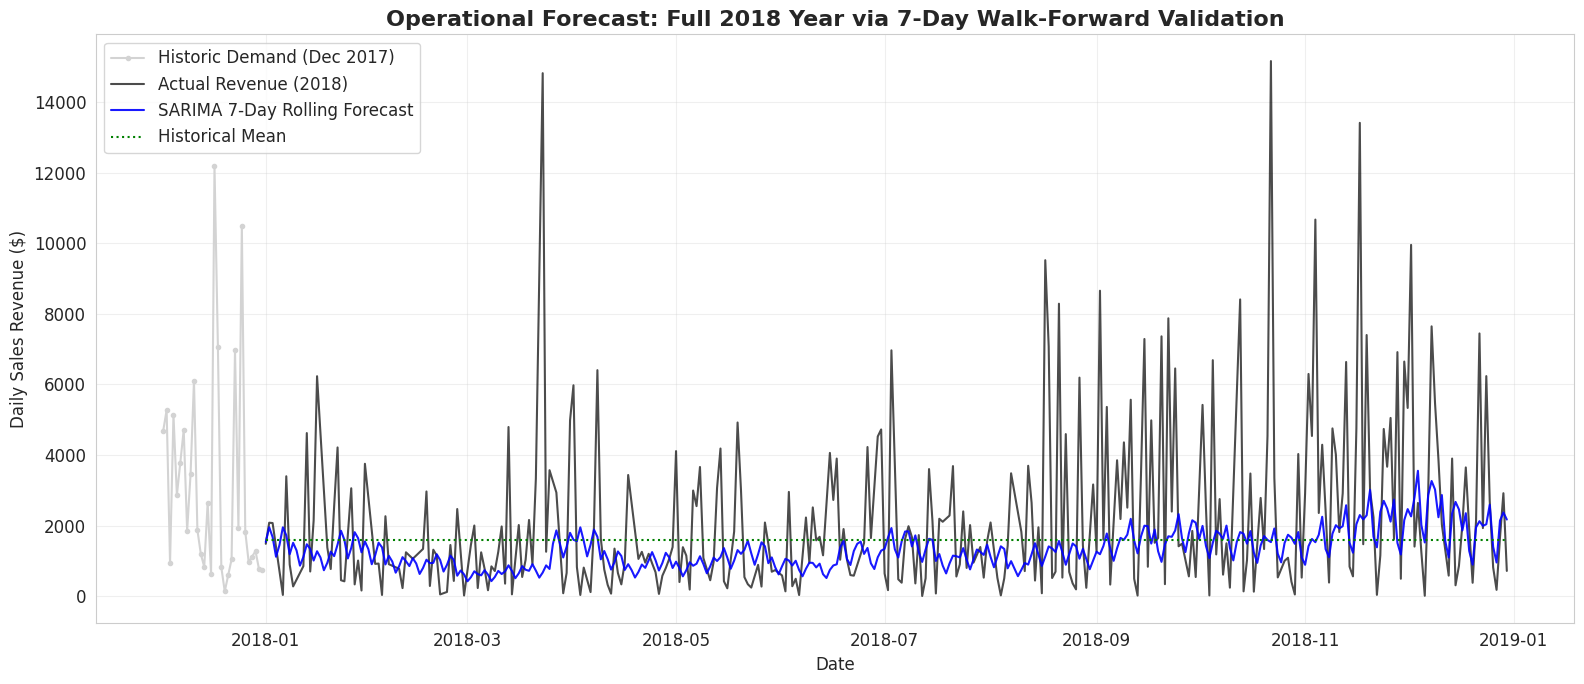

DAILY FINAL EVALUATION MATRIX


,Model,Target Frequency,MAE ($),RMSE ($)
0,Historical Mean,Daily,1541.56,2383.21
1,SARIMA Walk-Forward,Daily,1489.56,2380.60


In [84]:
print("Objective: Predict the entire year of 2018 using strict 7-day rolling forecasts.\n")
plt.figure(figsize=(16, 7))

context_train = train_d.iloc[-30:]
plt.plot(context_train.index, context_train['sales'], label='Historic Demand (Dec 2017)', color='lightgray', marker='.')
plt.plot(test_d.index, test_d['sales'], label='Actual Revenue (2018)', color='black', alpha=0.7)
plt.plot(test_d.index, best_preds_d, label='SARIMA 7-Day Rolling Forecast', color='blue', alpha=0.9, linewidth=1.5)
plt.plot(test_d.index, mean_pred_d, label='Historical Mean', color='green', linestyle=':')

plt.title('Operational Forecast: Full 2018 Year via 7-Day Walk-Forward Validation', fontsize=16, fontweight='bold')
plt.ylabel('Daily Sales Revenue ($)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# EVALUATION MATRIX OUTPUT
results_daily_df = pd.DataFrame({
    'Model': ['Historical Mean', 'SARIMA Walk-Forward'],
    'Target Frequency': ['Daily', 'Daily'],
    'MAE ($)': [mae_mean_d, mae_sarima_d],
    'RMSE ($)': [rmse_mean_d, rmse_sarima_d]
})

print("DAILY FINAL EVALUATION MATRIX")
display(results_daily_df.round(2))


The results show that SARIMA delivered modest improvement for the short-term daily forecasting horizon. Using 7-day walk-forward validation, the optimized model achieved an MAE of \$1,489.56 and RMSE of \$2,380.60, slightly outperforming the historical mean baseline.

This indicates that while the model captured short-term weekly demand structure, daily retail sales remained considerably more volatile and difficult to predict than monthly aggregated sales. Frequent revenue spikes and irregular day-to-day fluctuations reduced forecasting precision, highlighting the greater complexity of operational daily demand forecasting.

## Actuals vs Forecasted Comparison Table (first 2 weeks of 2018)

In [85]:
first_14_actuals = test_d['sales'].iloc[:14]
first_14_preds = best_preds_d.iloc[:14]

comparison_df_daily = pd.DataFrame({
    'Date': first_14_actuals.index.strftime('%Y-%m-%d'),
    'Actual Sales ($)': first_14_actuals.values,
    'SARIMA Forecast ($)': first_14_preds.values
})

comparison_df_daily['Difference ($)'] = comparison_df_daily['Actual Sales ($)'] - comparison_df_daily['SARIMA Forecast ($)']

print("\nFIRST 2 WEEKS (JAN 1 - JAN 14) ACTUALS VS FORECAST")
display(comparison_df_daily.round(2))


FIRST 2 WEEKS (JAN 1 - JAN 14) ACTUALS VS FORECAST


,Date,Actual Sales ($),SARIMA Forecast ($),Difference ($)
0,2018-01-01,1481.83,1535.22,-53.39
1,2018-01-02,2079.55,1951.47,128.09
2,2018-01-03,2070.27,1672.19,398.08
3,2018-01-04,1391.43,1115.00,276.43
4,2018-01-05,712.58,1444.36,-731.77
5,2018-01-06,33.74,1949.47,-1915.73
6,2018-01-07,3395.59,1722.26,1673.33
7,2018-01-08,892.98,1186.85,-293.87
8,2018-01-09,274.49,1509.66,-1235.17
9,2018-01-10,465.83,1294.82,-828.98


## Model Discussion: Stability, Interpretability, and Computational Considerations

The daily SARIMA walk-forward implementation exhibited lower forecasting stability compared to the monthly model. Daily retail sales contained substantial irregular fluctuations and abrupt revenue spikes, causing prediction accuracy to vary considerably across different periods of the 2018 test horizon.

Despite this volatility, the model remained interpretable. The selected SARIMA(0,1,1)(0,1,1,7) structure reflects weekly retail cyclicality, with seasonal terms explicitly capturing repeating consumer purchasing behavior across weekdays. The moving-average structure indicates that recent forecast errors played a stronger corrective role than long-range autoregressive persistence.

The primary computational limitation of the daily implementation was the walk-forward validation process. Unlike the monthly model, daily forecasting required repeated SARIMA retraining across 52 rolling weekly windows. This significantly increased computational cost and execution time.

However, this higher computational burden improved methodological rigor by preserving strict chronological validation and preventing data leakage.

From an operational business perspective, while daily SARIMA provides useful short-term demand signals, its sensitivity to irregular fluctuations suggests that more adaptive machine learning approaches may be preferable for real-time retail decision-making